In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = sns.load_dataset("titanic") # snste bulunan farklı datasetlerden

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info() #null değerler var

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# EDA

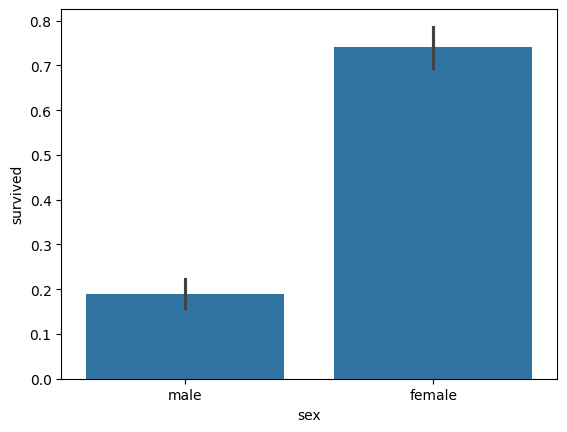

In [ ]:
sns.barplot(data=df, x="sex", y="survived")
plt.show()

In [ ]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


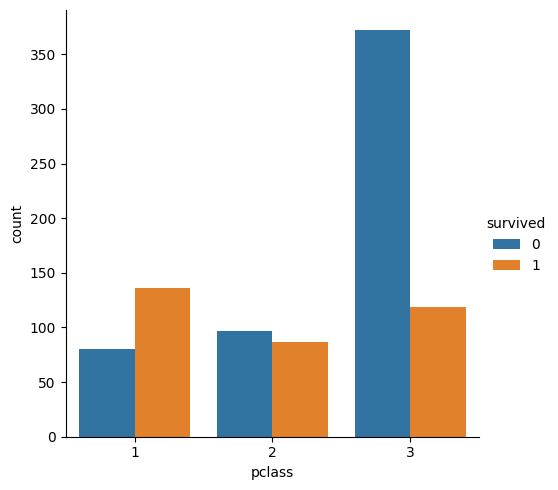

In [ ]:
sns.catplot(data=df, x="pclass", hue="survived", kind="count")
plt.show()

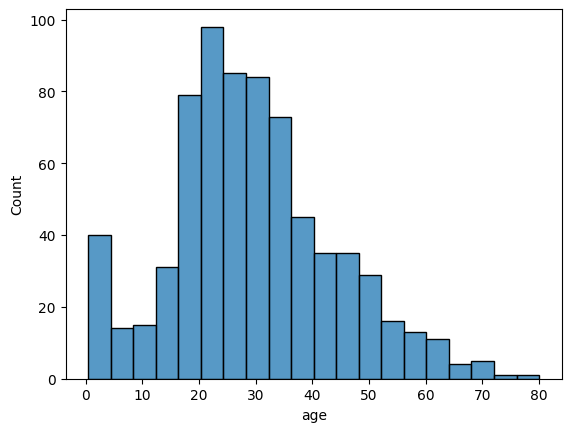

In [ ]:
sns.histplot(data=df, x="age")
plt.show()

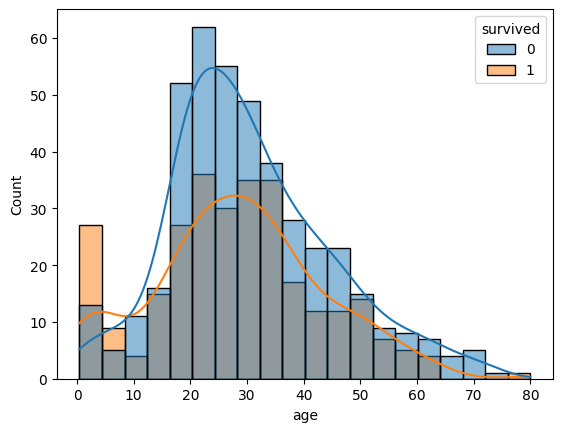

In [ ]:
sns.histplot(data=df, x="age", hue="survived", kde=True)
plt.show()

In [ ]:
df["who"].value_counts()

,count
who,
man,537
woman,271
child,83


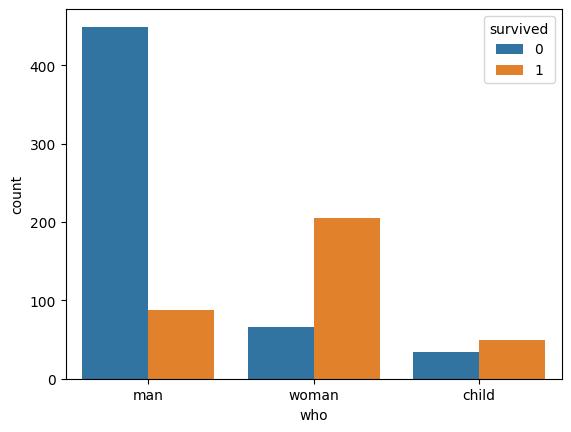

In [ ]:
sns.countplot(data=df, x="who", hue="survived")
plt.show()

# **FEATURE ENGINEERING**


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.shape

(891, 15)

In [ ]:
#bazı gereksiz görülen kolonlar atılacak
df= df.drop(["deck", "embark_town", "alive"],axis=1)

In [ ]:
df.isnull().sum()
# agede ve embarkedta boş

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df["age"]= df['age'].fillna(df['age'].median()) #agetaki boşları medyan ile doldurulacak
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0]) #embarkedtaki boşları en çok tekrar eden ile doldurulacak(mo dizi şeklinde ilerlediği için en baştaki[0] en çok tekrar edilen olacak)


In [ ]:
df['embarked'].value_counts()

,count
embarked,
S,646
C,168
Q,77


In [ ]:
df['embarked'].mode()[0]

'S'

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


aşağıdaki kolonlar kategorik, one hot encoding yapılabilir

In [ ]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


In [ ]:
df['class'].value_counts()

,count
class,
Third,491
First,216
Second,184


In [ ]:
df['embarked'].value_counts()

,count
embarked,
S,646
C,168
Q,77


In [ ]:
df['who'].value_counts()

,count
who,
man,537
woman,271
child,83


In [ ]:
df["alone"]

,alone
0,False
1,False
2,True
3,False
4,True
...,...
886,True
887,True
888,False
889,True


In [ ]:
#boolean türündekileri int yapmak
df["adult_male"] = df["adult_male"].astype(int)
df["alone"] = df["alone"].astype(int)

In [ ]:
df.adult_male

,adult_male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [ ]:
# x y
X=df.drop("survived", axis=1)
y=df["survived"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [ ]:
#onehot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn import preprocessing
categorical_cols = ["sex","class", "embarked", "who"]

preprocessor=ColumnTransformer(transformers=
    [
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
    )
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)


In [ ]:
encoded_cols = preprocessor.get_feature_names_out()

In [ ]:
#dataFrame çevir
X_train = pd.DataFrame(X_train, columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
clf= lgb.LGBMClassifier(verbosity=-1) # -1 yadım binlerce şey yazdırmasın diye
clf.fit(X_train, y_train)

LGBMClassifier(verbosity=-1)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       128
           1       0.75      0.76      0.75        95

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.79      0.79      0.79       223

[[104  24]
 [ 23  72]]


In [ ]:
importances=clf.feature_importances_

# yukarıdaki önem sırasını hangi kolona ait olduğunu daha açık bir şekilde görmek için:
feature_names = X_train.columns
feature_importance = pd.DataFrame(
    {
        "Feature" : feature_names,
        "Importance" : importances
    }
).sort_values(by="Importance", ascending=False)

In [ ]:
feature_importance # en büyüğe gore kolonları en önemliden dizmiş
#bu şekilde kolonların etkisini görmüş oluyoruz

,Feature,Importance
11,remainder__fare,1132
8,remainder__age,865
4,cat__embarked_S,81
10,remainder__parch,77
9,remainder__sibsp,65
0,cat__sex_male,60
2,cat__class_Third,51
13,remainder__alone,41
1,cat__class_Second,41
6,cat__who_woman,36


hyperparameter Tuning


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
lgb_model = lgb.LGBMClassifier(verbosity=-1)

In [ ]:
param_grid = {
    "n_estimators" : [100,300,500,100],
    "max_depth" : [3,5,7,-1],
    "learning_rate" : [0.01,0.05,0.1,0.3],
    "num_leaves": [15,31,63,64,127],
    "min_child_samples" : [10,20,30],
    "subsample": [0.6,0.8,1.0],
    "colsample_bytree" : [0.6,0.8,1.0],
}

In [ ]:
random_search= RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, -1],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 300, 500, 100],
                                        'num_leaves': [15, 31, 63, 64, 127],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='accuracy', verbose=1)

In [ ]:
random_search.best_params_

{'subsample': 0.6,
 'num_leaves': 31,
 'n_estimators': 300,
 'min_child_samples': 10,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 0.6}

In [ ]:
y_pred = random_search.predict(X_test)

In [ ]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87       131
           1       0.80      0.84      0.82        92

    accuracy                           0.85       223
   macro avg       0.84      0.85      0.84       223
weighted avg       0.85      0.85      0.85       223

[[112  19]
 [ 15  77]]


In [ ]:
from xgboost import XGBClassifier
xgb= XGBClassifier(n_estimator=100)
xgb.fit(X_train, y_train)
y_pred=xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:24:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

#xgboostun default ile yaklaşık yakın sonuçlar verdi

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       136
           1       0.72      0.79      0.75        87

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.79       223
weighted avg       0.80      0.80      0.80       223

[[109  27]
 [ 18  69]]


In [ ]:
params = {
    "n_estimators" : [100,300,500,100],
    "max_depth" : [3,5,7,-1],
    "learning_rate" : [0.01,0.05,0.1,0.3],
    "colsample_bytree" : [0.6,0.8,1.0],
}

In [ ]:
random_search= RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1806, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/di

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, -1],
                                        'n_estimators': [100, 300, 500, 100]},
                   scoring='accuracy')

In [ ]:
y_pred = random_search.predict(X_test)

In [ ]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       132
           1       0.79      0.84      0.81        91

    accuracy                           0.84       223
   macro avg       0.84      0.84      0.84       223
weighted avg       0.85      0.84      0.84       223

[[112  20]
 [ 15  76]]
